In [1]:
import openpyxl
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
import csv
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk import word_tokenize, bigrams
from nltk.corpus import stopwords
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')
# Download das stopwords em português se ainda não estiverem baixadas
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\carlo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
cluster_0 = './data_input/clusters/Oct_2022_cluster_0.csv'
cluster_1 = './data_input/clusters/Oct_2022_cluster_1.csv'
textos_encontrados = './data_input/texto_encontrados_out_2022.xlsx'

noticias_falsas_detectadas = './data_input/termos_chaves/NoticiaCompleta.xlsx'
textos_encontrados_unlabeled_cluster_0 = './resultados_v1/cluster_0/texto_encontrados_NoticiaCompleta_cluster_0.xlsx'
textos_encontrados_unlabeled_cluster_1 = './resultados_v1/cluster_1/texto_encontrados_NoticiaCompleta_cluster_1.xlsx'
textos_encontrados_labeled_cluster_0 = './resultados_v1/rotulado/cluster_0/Oct_2022_cluster_0_labeled_NoticiaCompleta.xlsx'
textos_encontrados_labeled_cluster_1 = './resultados_v1/rotulado/cluster_1/Oct_2022_cluster_1_labeled_NoticiaCompleta.xlsx'

In [3]:
def procurar_e_imprimir(textos, termos):
    nltk.download('punkt')
    resultados = {termo: [] for termo in termos}
    textos_utilizados = set()

    for termo in termos:
        bigramas_termo = list(bigrams(termo.lower().split()))
        textos_encontrados = 0

        for texto in textos:
            if texto['text'] in textos_utilizados:
                continue

            texto_lower = texto['text'].lower()
            palavras_texto = word_tokenize(texto_lower)
            bigramas_texto = list(bigrams(palavras_texto))
            count = sum(1 for bigrama in bigramas_termo if bigrama in bigramas_texto)

            if count >= 1:  # Verifica se pelo menos 1 bigramas do termo estão no texto
                texto['correspondencia'] = count
                resultados[termo].append(texto)
                textos_utilizados.add(texto['text'])
                textos_encontrados += 1

    return resultados

def main():
    # Carregar termos da coluna da planilha .xlsx
    wb = openpyxl.load_workbook(noticias_falsas_detectadas)
    planilha = wb['Sheet1']
    
    # Extrair termos-chave da coluna 'Termos_chave' (coluna F)
    termos = [celula.value for celula in planilha['F'] if celula.value]

    # Carregar textos da coluna 'text' do arquivo CSV e remover duplicatas
    with open(cluster_0, 'r', encoding='utf-8') as arquivo:
        leitor_csv = csv.DictReader(arquivo)
        textos = [{key: row[key] for key in row} for row in leitor_csv if row['text']]

    # Procurar e imprimir textos relevantes para cada termo
    resultados = procurar_e_imprimir(textos, termos)

    # Criar lista de dicionários para os resultados
    lista_resultados = []
    for termo, textos_relevantes in resultados.items():
        for texto in textos_relevantes:
            texto['termo'] = termo
            lista_resultados.append(texto)

    # Criar DataFrame a partir da lista de dicionários
    df_resultados = pd.DataFrame(lista_resultados)

    # Salvar os resultados em um arquivo Excel
    df_resultados.to_excel(textos_encontrados_unlabeled_cluster_0, index=False)

    print('Resultados salvos com sucesso.')

if __name__ == "__main__":
    main()

[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Resultados salvos com sucesso.


In [4]:
def procurar_e_imprimir(textos, termos):
    nltk.download('punkt')
    resultados = {termo: [] for termo in termos}
    textos_utilizados = set()

    for termo in termos:
        bigramas_termo = list(bigrams(termo.lower().split()))
        textos_encontrados = 0

        for texto in textos:
            if texto['text'] in textos_utilizados:
                continue

            texto_lower = texto['text'].lower()
            palavras_texto = word_tokenize(texto_lower)
            bigramas_texto = list(bigrams(palavras_texto))
            count = sum(1 for bigrama in bigramas_termo if bigrama in bigramas_texto)

            if count >= 1:  # Verifica se pelo menos 1 bigramas do termo estão no texto
                texto['correspondencia'] = count
                resultados[termo].append(texto)
                textos_utilizados.add(texto['text'])
                textos_encontrados += 1

            
    return resultados

def main():
    # Carregar termos da coluna da planilha .xlsx
    wb = openpyxl.load_workbook(noticias_falsas_detectadas)
    planilha = wb['Sheet1']
    
    # Extrair termos-chave da coluna 'Termos_chave' (coluna F)
    termos = [celula.value for celula in planilha['F'] if celula.value]

    # Carregar textos da coluna 'text' do arquivo CSV e remover duplicatas
    with open(cluster_1, 'r', encoding='utf-8') as arquivo:
        leitor_csv = csv.DictReader(arquivo)
        textos = [{key: row[key] for key in row} for row in leitor_csv if row['text']]

    # Procurar e imprimir textos relevantes para cada termo
    resultados = procurar_e_imprimir(textos, termos)

    # Criar lista de dicionários para os resultados
    lista_resultados = []
    for termo, textos_relevantes in resultados.items():
        for texto in textos_relevantes:
            texto['termo'] = termo
            lista_resultados.append(texto)

    # Criar DataFrame a partir da lista de dicionários
    df_resultados = pd.DataFrame(lista_resultados)

    # Salvar os resultados em um arquivo Excel
    df_resultados.to_excel(textos_encontrados_unlabeled_cluster_1, index=False)

    print('Resultados salvos com sucesso.')

if __name__ == "__main__":
    main()

[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Resultados salvos com sucesso.


In [5]:
# Função para carregar os dados rotulados de uma planilha Excel
def load_excel(file_path, sheet_name):
    labeled_data = pd.read_excel(file_path, sheet_name=sheet_name)
    return labeled_data

# Função para carregar os dados não rotulados de um arquivo CSV
def load_csv(file_path):
    unlabeled_data = pd.read_csv(file_path)
    return unlabeled_data

# Função para rotular os textos não rotulados usando similaridade de cosseno
def label_unlabeled_data(unlabeled_data, labeled_data, vectorizer, threshold=0.9):
    X_unlabeled_tfidf = vectorizer.transform(unlabeled_data['text'])
    X_labeled_tfidf = vectorizer.transform(labeled_data['text'])
    labels = []
    similarities = []
    similar_terms = []

    for i in range(X_unlabeled_tfidf.shape[0]):
        similarity_scores = cosine_similarity(X_unlabeled_tfidf[i], X_labeled_tfidf)
        max_similarity = similarity_scores.max()
        similarities.append(max_similarity)

        if max_similarity > threshold:
            similar_doc_index = similarity_scores.argmax()
            labels.append(labeled_data.iloc[similar_doc_index]['desinformacao'])
            similar_terms.append(labeled_data.iloc[similar_doc_index]['Termos_chave'])  # Pega o termo associado
        else:
            labels.append(-1)
            similar_terms.append(None)

    return labels, similarities, similar_terms

In [6]:
# Carregar os dados rotulados e não rotulados
labeled_data = load_excel(textos_encontrados, 'Cluster_1')
unlabeled_data = load_excel(textos_encontrados_unlabeled_cluster_1, 'Sheet1')

# Vetorizar os textos rotulados com TF-IDF
vectorizer = TfidfVectorizer().fit(labeled_data['text'])

# Rotular os textos não rotulados e obter as similaridades e termos
labels, similarities, similar_terms = label_unlabeled_data(unlabeled_data, labeled_data, vectorizer)

# Adicionar os rótulos, similaridades e termos ao DataFrame não rotulado
unlabeled_data['desinformacao'] = labels
unlabeled_data['similaridade'] = similarities
unlabeled_data['termo_similar'] = similar_terms

# Salvar todos os dados rotulados e não rotulados em um novo Excel
output_path = textos_encontrados_labeled_cluster_1
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)

# Filtrar os dados que não foram rotulados (-1)
unlabeled_unlabeled = unlabeled_data[unlabeled_data['desinformacao'] == -1]

# Salvar os dados não rotulados em uma aba separada
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)
    unlabeled_unlabeled.to_excel(writer, sheet_name='Não Rotulados', index=False)

print(f"Dados salvos em: {output_path}")

Dados salvos em: ./resultados_v1/rotulado/cluster_1/Oct_2022_cluster_1_labeled_NoticiaCompleta.xlsx


In [7]:
# Carregar os dados rotulados e não rotulados
labeled_data = load_excel(textos_encontrados, 'Cluster_0')
unlabeled_data = load_excel(textos_encontrados_unlabeled_cluster_0, 'Sheet1')

# Vetorizar os textos rotulados com TF-IDF
vectorizer = TfidfVectorizer().fit(labeled_data['text'])

# Rotular os textos não rotulados e obter as similaridades e termos
labels, similarities, similar_terms = label_unlabeled_data(unlabeled_data, labeled_data, vectorizer)

# Adicionar os rótulos, similaridades e termos ao DataFrame não rotulado
unlabeled_data['desinformacao'] = labels
unlabeled_data['similaridade'] = similarities
unlabeled_data['termo_similar'] = similar_terms

# Salvar todos os dados rotulados e não rotulados em um novo Excel
output_path = textos_encontrados_labeled_cluster_0
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)

# Filtrar os dados que não foram rotulados (-1)
unlabeled_unlabeled = unlabeled_data[unlabeled_data['desinformacao'] == -1]

# Salvar os dados não rotulados em uma aba separada
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)
    unlabeled_unlabeled.to_excel(writer, sheet_name='Não Rotulados', index=False)

print(f"Dados salvos em: {output_path}")

Dados salvos em: ./resultados_v1/rotulado/cluster_0/Oct_2022_cluster_0_labeled_NoticiaCompleta.xlsx


In [8]:
def contar_termos_com_desinformacao(df):
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df[df['desinformacao'].str.lower() == 'sim']
    
    # Contar a frequência dos termos nos textos com desinformação
    termo_counts = df_desi_texts['termo'].value_counts()
    
    return termo_counts

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_1, sheet_name='Rotulados')
    
    # Contar os termos que possuem "sim" na coluna desinformacao
    termo_counts = contar_termos_com_desinformacao(df_desi)
    
    # Ordenar e selecionar os top 5 termos mais frequentes
    top_5_termos = termo_counts.head(5)
    
    # Exibir os 5 termos mais frequentes com desinformação
    for termo, count in top_5_termos.items():
        print(f"Termo: {termo}, Quantidade de Desinformação: {count}")

if __name__ == "__main__":
    main()

Termo: aos fatosf: compartilhe é falso que o tse (tribunal superior eleitoral) não testou a segurança das urnas para as eleições de 2022 ou que as vulnerabilidades encontradas no sistema em 2012 ainda não foram corrigidas, como afirmam postagens (veja aqui). a alegação enganosa se baseia em um vídeo gravado em 2014 em que diego aranha, professor assistente de segurança de sistemas na universidade de aarhus, na dinamarca, anuncia o projeto você fiscal, mas os problemas citados por ele na gravação já foram sanados pela justiça eleitoral. as postagens enganosas circulam principalmente no twitter, em que acumulam mais de 2.000 compartilhamentos, e também no whatsapp, rede em que não é possível estimar o alcance. um vídeo de 2014 em que o especialista em segurança digital diego aranha apresenta o projeto você fiscal circula nas redes fora de contexto para sugerir que há vulnerabilidades nas urnas e que o tse (tribunal superior eleitoral) não realizou testes públicos de verificação de segura

In [9]:
def contar_termos_com_desinformacao(df):
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df[df['desinformacao'].str.lower() == 'sim']
    
    # Contar a frequência dos termos nos textos com desinformação
    termo_counts = df_desi_texts['termo'].value_counts()
    
    return termo_counts

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_0, sheet_name='Rotulados')
    
    # Imprimir textos com maior correspondência (coluna correspondencia)
    top_textos = df_desi.sort_values(by='correspondencia', ascending=False).head(5)
    print("\nTextos com Maior Correspondência:")
    for idx, row in top_textos.iterrows():
        print(f"Texto: {row['text']}, Correspondência: {row['correspondencia']}")
        
        # Calcular a média da correspondência dos top textos
    media_correspondencia = top_textos['correspondencia'].mean()
    print(f"\nMédia da Correspondência dos Top Textos: {media_correspondencia}")
    
    # Calcular a média da correspondência de todos os textos
    media_correspondencia = df_desi['correspondencia'].mean()
    print(f"\nMédia da Correspondência de Todos os Textos: {media_correspondencia}")

if __name__ == "__main__":
    main()


Textos com Maior Correspondência:
Texto: @LulaOficial O CONGRESSO PODE E DEVE EXIGIR VOTO IMPRESSO NO 2° TURNO. OLAVO VEIO DAR A SOLUÇÃO, CONTRA A FRAUDE ELEITORAL. https://t.co/TBe5Fj2E7T, Correspondência: 15
Texto: @GayerGus Desde o dia que o Barroso impediu a aprovação da PEC do voto impresso na CCJ que convivo com o fanfasma da derrota do PR nas urnas. Não me surpreendeu o resultado. Há muito formei a convicção de que o TSE é o mecanismo através do qual o STF controla o sistema., Correspondência: 13
Texto: @Herbye46 @DanielMutton6 Pessoal, o saudoso Olavo de Carvalho deixou um vídeo dizendo que se o povo for às ruas, exigindo que o Congresso vote (em regime de urgência) o Voto Impresso para o segundo turno, é possível, pois não é cláusula pétrea!
🤔🇧🇷🙏🤖😎👉 https://t.co/jHkoOecEEI, Correspondência: 12
Texto: @EdRaposo_ E esse plano já se delineava há mais de um ano, a partir do momento em que o $upr£mo interferiu na votação da Câmara "convencendo" os líderes dos partidos a votarem co

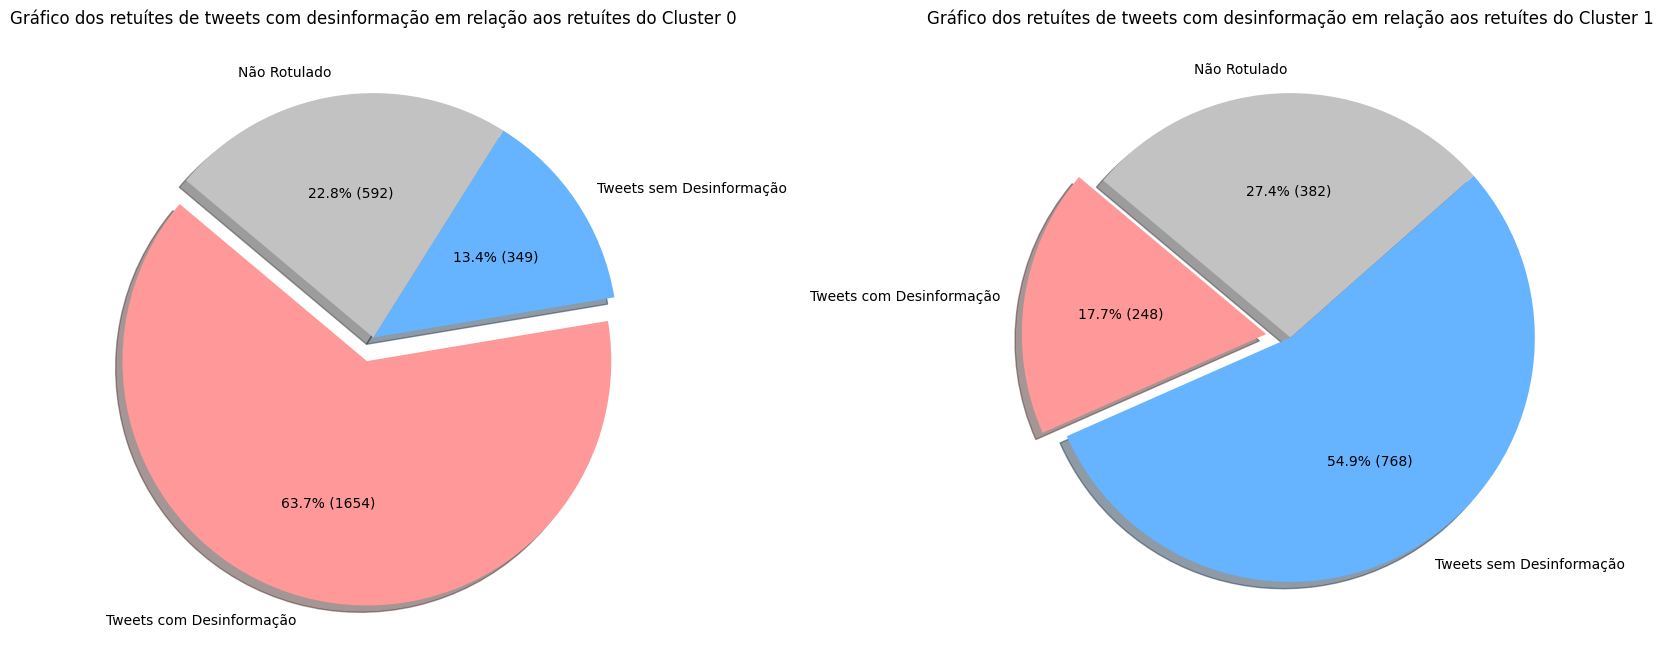

In [10]:
def criar_grafico_desinformacao(df_cluster, df_desi, ax, titulo):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar contadores
    total_textos = df_cluster_unique.shape[0]
    desinformacao_count = 0
    nao_rotulado_count = 0
    
    # Iterar sobre os textos únicos no cluster
    df_merged = df_cluster_unique.merge(df_desi[['text', 'desinformacao']], on='text', how='left')

    df_merged['desinformacao_norm'] = df_merged['desinformacao'].str.strip().str.lower()

    desinformacao_count = (df_merged['desinformacao_norm'] == 'sim').sum()
    nao_rotulado_count = df_merged['desinformacao_norm'].isna().sum()

    # Calcular a porcentagem de desinformação
    total_rotulado = total_textos - nao_rotulado_count
    porcentagem_desinformacao = (desinformacao_count / total_rotulado) * 100 if total_rotulado > 0 else 0
    
    # Criar gráfico de pizza
    labels = ['Tweets com Desinformação', 'Tweets sem Desinformação', 'Não Rotulado']
    sizes = [desinformacao_count, total_rotulado - desinformacao_count, nao_rotulado_count]
    colors = ['#ff9999', '#66b3ff', '#c2c2c2']
    explode = (0.1, 0, 0)  # Explode 1st slice
    
    ax.pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct=lambda p: f'{p:.1f}% ({int(p * total_textos / 100):d})', shadow=True, startangle=140)
    ax.set_title(titulo)

def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster_0 = pd.read_csv(cluster_0)
    df_cluster_1 = pd.read_csv(cluster_1)

    # Carregar dados de desinformação
    df_desi_0 = pd.read_excel(textos_encontrados_labeled_cluster_0, sheet_name='Rotulados')
    df_desi_1 = pd.read_excel(textos_encontrados_labeled_cluster_1, sheet_name='Rotulados')

    # Criar figura e eixos para subplots
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    # Criar gráficos
    criar_grafico_desinformacao(df_cluster_0, df_desi_0, axs[0], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 0')
    criar_grafico_desinformacao(df_cluster_1, df_desi_1, axs[1], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 1')

    # Mostrar os gráficos
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

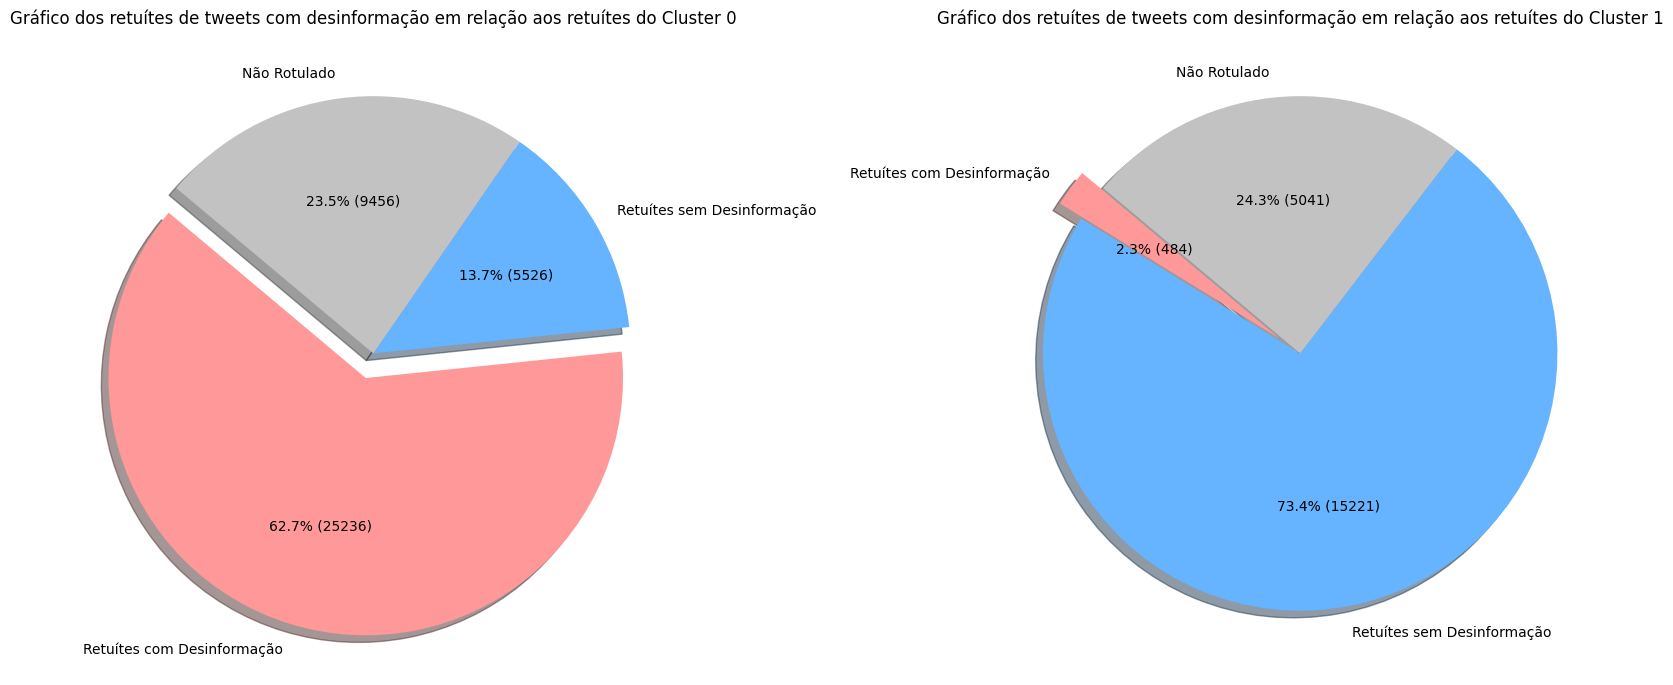

In [11]:
def criar_grafico_desinformacao(df_cluster, df_desi, ax, titulo):
    # Inicializar contadores
    total_textos = df_cluster.shape[0]
    desinformacao_count = 0
    nao_rotulado_count = 0
    
    # Iterar sobre todos os textos no cluster
    df_merged = df_cluster.merge(df_desi[['text', 'desinformacao']], on='text', how='left')

    df_merged['desinformacao_norm'] = df_merged['desinformacao'].str.strip().str.lower()

    desinformacao_count = (df_merged['desinformacao_norm'] == 'sim').sum()
    nao_rotulado_count = df_merged['desinformacao_norm'].isna().sum()

    # Calcular a porcentagem de desinformação
    total_rotulado = total_textos - nao_rotulado_count
    porcentagem_desinformacao = (desinformacao_count / total_rotulado) * 100 if total_rotulado > 0 else 0
    
    # Criar gráfico de pizza
    labels = ['Retuítes com Desinformação', 'Retuítes sem Desinformação', 'Não Rotulado']
    sizes = [desinformacao_count, total_rotulado - desinformacao_count, nao_rotulado_count]
    colors = ['#ff9999', '#66b3ff', '#c2c2c2']
    explode = (0.1, 0, 0)  # Explode 1st slice
    
    ax.pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct=lambda p: f'{p:.1f}% ({int(p * total_textos / 100):d})', shadow=True, startangle=140)
    ax.set_title(titulo)

def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster_0 = pd.read_csv(cluster_0)
    df_cluster_1 = pd.read_csv(cluster_1)
    
    # Carregar dados de desinformação
    df_desi_0 = pd.read_excel(textos_encontrados_labeled_cluster_0, sheet_name='Rotulados')
    df_desi_1 = pd.read_excel(textos_encontrados_labeled_cluster_1, sheet_name='Rotulados')
    
    # Criar figura e eixos para subplots
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    # Criar gráficos

    criar_grafico_desinformacao(df_cluster_0, df_desi_0, axs[0], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 0')
    criar_grafico_desinformacao(df_cluster_1, df_desi_1, axs[1], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 1')
    # Mostrar os gráficos
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

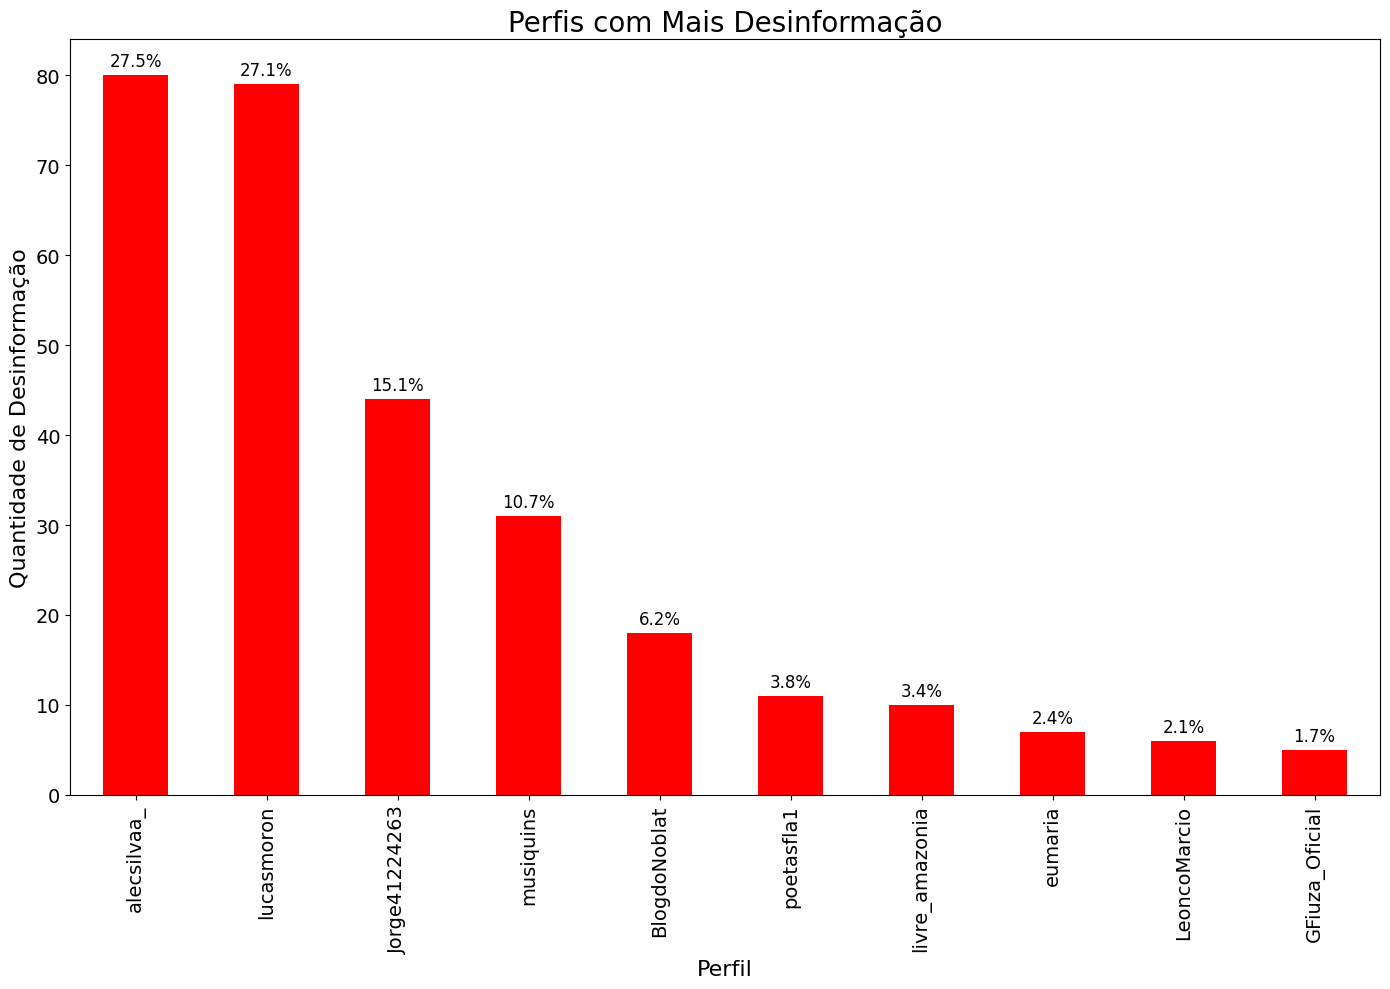

In [12]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Identificar textos com desinformação (considerando todas as ocorrências)
    df_desi_texts = df_desi[df_desi['desinformacao'].str.lower() == 'sim']
    textos_com_desi = df_desi_texts['text']
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts_cluster = df_cluster[df_cluster['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts_cluster['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(14, 10))
    bars = perfil_counts.plot(kind='bar', color='red')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação', fontsize=20)
    plt.xlabel('Perfil', fontsize=16)
    plt.ylabel('Quantidade de Desinformação', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação (substitua pelo seu caminho real)
    df_cluster = pd.read_csv(cluster_1)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_1, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()

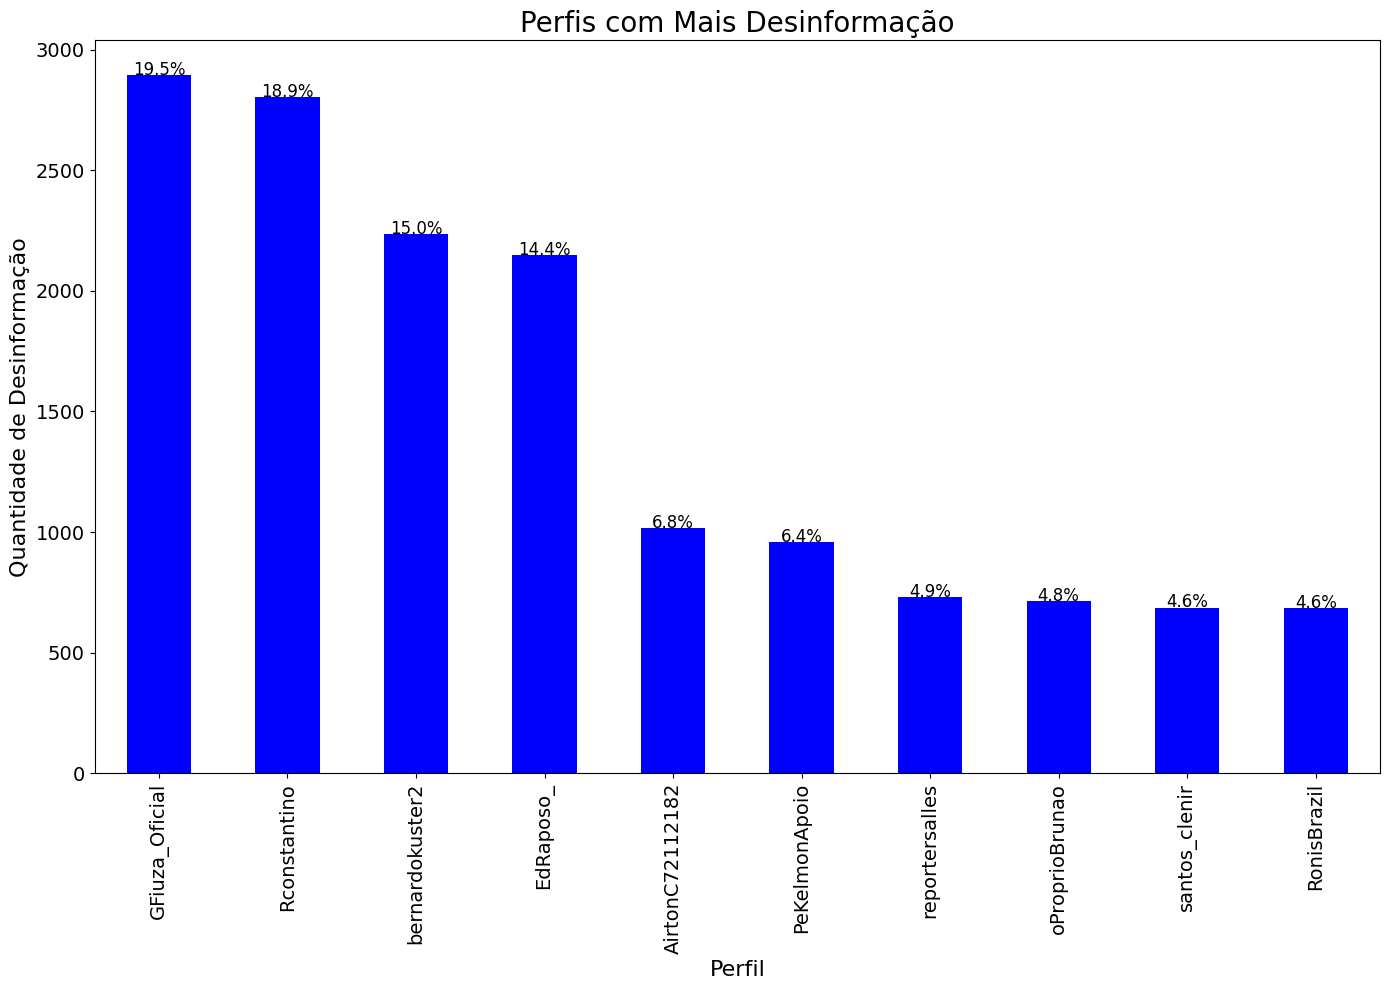

In [13]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Identificar textos com desinformação (considerando todas as ocorrências)
    df_desi_texts = df_desi[df_desi['desinformacao'].str.lower() == 'sim']
    textos_com_desi = df_desi_texts['text']
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts_cluster = df_cluster[df_cluster['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts_cluster['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(14, 10))
    bars = perfil_counts.plot(kind='bar', color='blue')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação', fontsize=20)
    plt.xlabel('Perfil', fontsize=16)
    plt.ylabel('Quantidade de Desinformação', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação (substitua pelo seu caminho real)
    df_cluster = pd.read_csv(cluster_0)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_0, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()

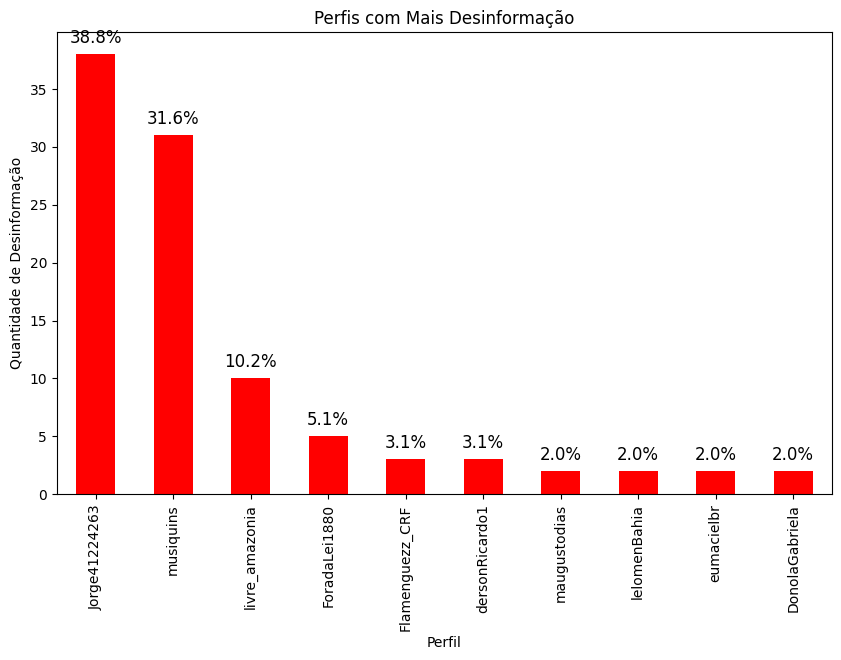

In [14]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar lista de textos com desinformação
    textos_com_desi = []
    
    # Adicionar todos os textos da planilha com desinformação 'sim'
    for text in df_cluster_unique['text']:
        if df_desi[(df_desi['text'] == text) & (df_desi['desinformacao'].str.lower() == 'sim')].shape[0] > 0:
            textos_com_desi.append(text)
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df_cluster_unique[df_cluster_unique['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(10, 6))
    bars = perfil_counts.plot(kind='bar', color='red')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação')
    plt.xlabel('Perfil')
    plt.ylabel('Quantidade de Desinformação')
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster = pd.read_csv(cluster_1)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_1, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()

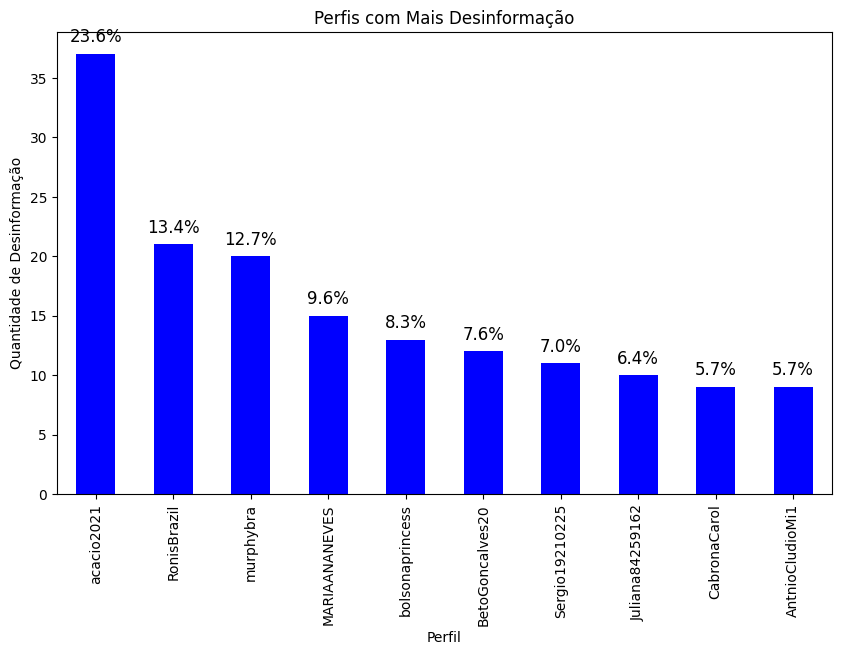

In [15]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar lista de textos com desinformação
    textos_com_desi = []
    
    # Adicionar todos os textos da planilha com desinformação 'sim'
    for text in df_cluster_unique['text']:
        if df_desi[(df_desi['text'] == text) & (df_desi['desinformacao'].str.lower() == 'sim')].shape[0] > 0:
            textos_com_desi.append(text)
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df_cluster_unique[df_cluster_unique['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(10, 6))
    bars = perfil_counts.plot(kind='bar', color='blue')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação')
    plt.xlabel('Perfil')
    plt.ylabel('Quantidade de Desinformação')
    plt.show()

def main():
    # Carregar CSV de textos encontrados e desinformação (substitua pelo seu caminho real)
    df_cluster = pd.read_csv(cluster_0)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_0, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()

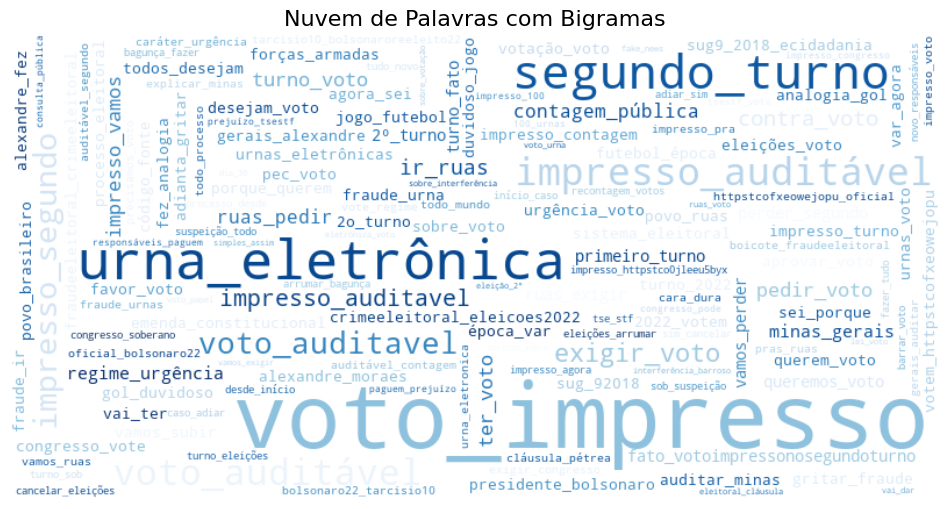

In [16]:
def extrair_bigramas(textos, termos):
    # Tokenizar os textos em palavras, removendo vírgulas
    textos_tokenizados = [word_tokenize(re.sub(r'[^\w\s]', '', texto.lower())) for texto in textos]
    
    # Lista de stopwords em português
    stop_words = set(stopwords.words('portuguese'))
    
    # Inicializar lista para armazenar bigramas
    bigram_list = []
    
    # Formar bigramas com base nos textos, ignorando stopwords e palavras isoladas
    for texto_tokenizado in textos_tokenizados:
        filtered_texto = [word for word in texto_tokenizado if word not in stop_words and len(word) > 1]
        bigram_list.extend(list(bigrams(filtered_texto)))
    
    # Contar a frequência dos bigramas nos textos
    bigram_counts = Counter()
    for bigram in bigram_list:
        bigram_counts['_'.join(bigram)] += 1
    
    return bigram_counts

def criar_nuvem_de_palavras(bigram_counts):
    if len(bigram_counts) == 0:
        print("Não foram encontrados bigramas nos textos.")
        return
    
    # Obter os 150 bigramas mais frequentes
    top_bigrams = bigram_counts.most_common(150)
    
    # Preparar os dados para a nuvem de palavras
    wordcloud_dict = {bigram.replace(' ', '_'): count for bigram, count in bigram_counts.items()}
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=150, prefer_horizontal=0.8)
    wordcloud.generate_from_frequencies(wordcloud_dict)
    
    # Definir estilos para os bigramas mais frequentes
    default_style = {
        'font_size': 12,
        'color': 'black',
        'regexp': r'\w[\w\s]*\w'
    }
    
    # Estilos modificados para os top bigramas
    highlighted_style = {
        **default_style,
        'font_size': 30,
        'color': 'blue',
        'font_path': None,
        'bold': True,
        'italic': True,
        'collocations': False
    }
    
    # Atualizar o estilo para os bigramas mais frequentes
    for bigram, _ in top_bigrams:
        wordcloud_dict[bigram.replace(' ', '_')] = 1
    
    # Plotar a nuvem de palavras
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuvem de Palavras com Bigramas', fontsize=16)
    plt.show()

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_0, sheet_name='Rotulados')
    
    # Extrair textos e termos
    textos = df_desi['text'].tolist()
    termos = df_desi['termo'].tolist()
    
    # Extrair bigramas dos textos e contar
    bigram_counts = extrair_bigramas(textos, termos)
    
    # Criar nuvem de palavras dos bigramas encontrados
    criar_nuvem_de_palavras(bigram_counts)

if __name__ == "__main__":
    main()

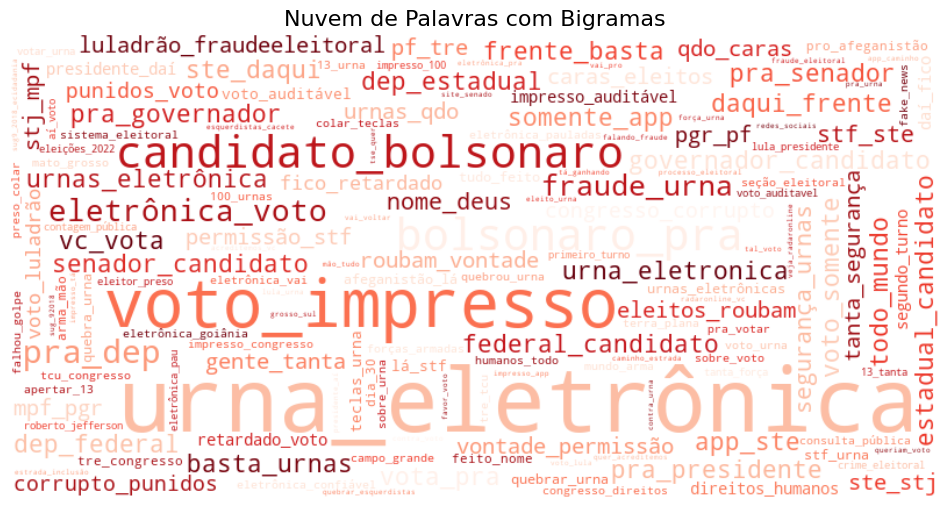

In [17]:
def extrair_bigramas(textos, termos):
    # Tokenizar os textos em palavras, removendo vírgulas
    textos_tokenizados = [word_tokenize(re.sub(r'[^\w\s]', '', texto.lower())) for texto in textos]
    
    # Lista de stopwords em português
    stop_words = set(stopwords.words('portuguese'))
    
    # Inicializar lista para armazenar bigramas
    bigram_list = []
    
    # Formar bigramas com base nos textos, ignorando stopwords e palavras isoladas
    for texto_tokenizado in textos_tokenizados:
        filtered_texto = [word for word in texto_tokenizado if word not in stop_words and len(word) > 1]
        bigram_list.extend(list(bigrams(filtered_texto)))
    
    # Contar a frequência dos bigramas nos textos
    bigram_counts = Counter()
    for bigram in bigram_list:
        bigram_counts['_'.join(bigram)] += 1
    
    return bigram_counts

def criar_nuvem_de_palavras(bigram_counts):
    if len(bigram_counts) == 0:
        print("Não foram encontrados bigramas nos textos.")
        return
    
    # Obter os 150 bigramas mais frequentes
    top_bigrams = bigram_counts.most_common(150)
    
    # Preparar os dados para a nuvem de palavras
    wordcloud_dict = {bigram.replace(' ', '_'): count for bigram, count in bigram_counts.items()}
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=150, prefer_horizontal=0.8)
    wordcloud.generate_from_frequencies(wordcloud_dict)
    
    # Definir estilos para os bigramas mais frequentes
    default_style = {
        'font_size': 12,
        'color': 'black',
        'regexp': r'\w[\w\s]*\w'
    }
    
    # Estilos modificados para os top bigramas
    highlighted_style = {
        **default_style,
        'font_size': 30,
        'color': 'blue',
        'font_path': None,
        'bold': True,
        'italic': True,
        'collocations': False
    }
    
    # Atualizar o estilo para os bigramas mais frequentes
    for bigram, _ in top_bigrams:
        wordcloud_dict[bigram.replace(' ', '_')] = 1
    
    # Plotar a nuvem de palavras
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuvem de Palavras com Bigramas', fontsize=16)
    plt.show()

def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel(textos_encontrados_labeled_cluster_1, sheet_name='Rotulados')
    
    # Extrair textos e termos
    textos = df_desi['text'].tolist()
    termos = df_desi['termo'].tolist()
    
    # Extrair bigramas dos textos e contar
    bigram_counts = extrair_bigramas(textos, termos)
    
    # Criar nuvem de palavras dos bigramas encontrados
    criar_nuvem_de_palavras(bigram_counts)

if __name__ == "__main__":
    main()